# AHMED AHSRAF SAAD 7628 ASSIGNMENT 1





## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from keras import layers
from google.colab import files
import matplotlib.pyplot as plt
from keras.models import Model
from keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# Upload the dataset
uploaded_files = files.upload()

# Setting up plot size for visualizations
plt.rcParams['figure.figsize'] = (10, 6)


Saving orbit.csv to orbit (1).csv


## Load Data

In [20]:
orbit_data = pd.read_csv("orbit.csv")

# Checking the first few rows to confirm data loading
orbit_data.sample(5)


,time_steps,y
1922,9.229615,85.185789
863,-1.365683,1.865090
1501,5.017509,25.175394
1314,3.146573,9.900923
1001,0.015008,0.000225


## Seperate data to numpy array

In [21]:
time_series = orbit_data['time_steps'].to_numpy()
vertical_positions = orbit_data['y'].to_numpy()


In [22]:
# Define split proportions
train_ratio = 0.7
val_ratio = 0.1
test_ratio = 0.2

# Calculate split indices
total_samples = len(time_series_combined)
train_size = int(train_ratio * total_samples)
val_size = int(val_ratio * total_samples)

# Train, validation, and test split
X_train = time_series_combined[:train_size]
y_train = vertical_positions_combined[:train_size]

X_val = time_series_combined[train_size:train_size + val_size]
y_val = vertical_positions_combined[train_size:train_size + val_size]

X_test = time_series_combined[train_size + val_size:]
y_test = vertical_positions_combined[train_size + val_size:]

# Check sizes
print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")


Train set size: 2800
Validation set size: 400
Test set size: 800


##Build the model (Try to change nb of units, nb of layers, adding dropout layers)

In [23]:
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers
from keras.layers import Dropout
from keras.callbacks import EarlyStopping



# Initialize a new model
neural_net = Sequential()

# Input layer followed by multiple hidden layers with regularization
neural_net.add(Dense(128, input_shape=(1,), activation='relu'))
neural_net.add(Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
neural_net.add(layers.Dropout(0.15))
neural_net.add(Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)))
neural_net.add(layers.Dropout(0.15))
neural_net.add(Dense(16, activation='relu', kernel_regularizer=regularizers.l2(0.001)))

# Output layer without activation (regression)
neural_net.add(Dense(1))
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr_on_plateau = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-5, verbose=1)




##Compile the model

In [24]:
# Compile the neural network model for regression

neural_net.compile(optimizer='adam', loss='mse')

# Define EarlyStopping to stop training when the model stops improving
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


##Train and Evalute the model

In [25]:
# Train the neural network on the provided dataset
neural_net.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[reduce_lr_on_plateau, early_stopping]
)

# Evaluate the model's performance on the test dataset
final_loss = neural_net.evaluate(X_test, y_test)
print("Final model loss (on test data):", final_loss)


Epoch 1/300
88/88 [==============================] - 1s 4ms/step - loss: 1008.1900 - val_loss: 147.1111 - lr: 0.0010
Epoch 2/300
88/88 [==============================] - 0s 2ms/step - loss: 189.3814 - val_loss: 120.8634 - lr: 0.0010
Epoch 3/300
88/88 [==============================] - 0s 2ms/step - loss: 149.5138 - val_loss: 97.1935 - lr: 0.0010
Epoch 4/300
88/88 [==============================] - 0s 2ms/step - loss: 126.2522 - val_loss: 69.2483 - lr: 0.0010
Epoch 5/300
88/88 [==============================] - 0s 2ms/step - loss: 90.8905 - val_loss: 41.6186 - lr: 0.0010
Epoch 6/300
88/88 [==============================] - 0s 2ms/step - loss: 62.6116 - val_loss: 21.1844 - lr: 0.0010
Epoch 7/300
88/88 [==============================] - 0s 2ms/step - loss: 58.4485 - val_loss: 22.1314 - lr: 0.0010
Epoch 8/300
88/88 [==============================] - 0s 2ms/step - loss: 48.8443 - val_loss: 15.5553 - lr: 0.0010
Epoch 9/300
88/88 [==============================] - 0s 2ms/step - loss: 43.7666 

##Predict with the model

In [26]:
def visualize_orbit(predicted_trajectory):
    axis_limit = int(len(predicted_trajectory) / 2)

    # Plot the reference orbit (scientist's prediction)
    plt.plot(np.arange(-axis_limit, axis_limit + 1), np.arange(-axis_limit, axis_limit + 1) ** 2,
             color="mediumseagreen")

    # Plot the predicted orbit based on model output
    plt.plot(np.arange(-axis_limit, axis_limit + 1), predicted_trajectory, color="darkorange")

    plt.axis([-40, 41, -5, 550])
    plt.legend(["Scientist's Predicted Orbit", "Model's Predicted Orbit"], loc="lower left")
    plt.title("Comparison of Model's Orbit and Scientist's Orbit")
    plt.show()


# Compare With the Scientist's Orbit

3/3 [==============================] - 0s 2ms/step


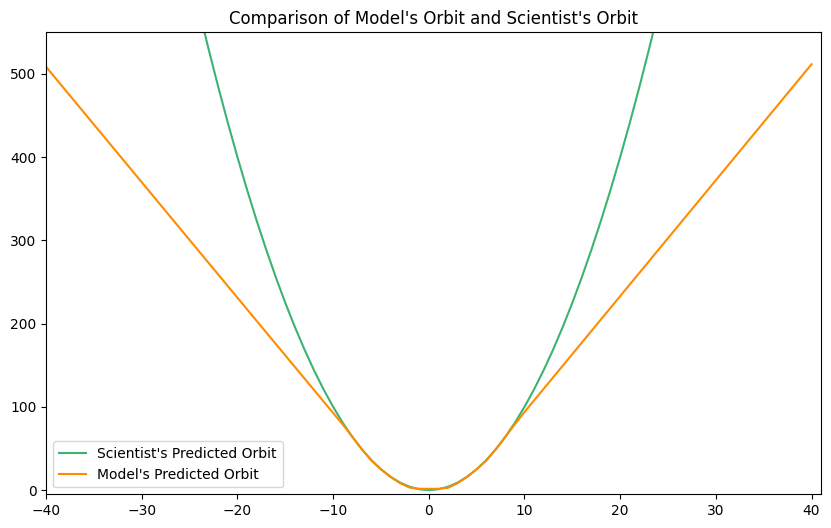

In [27]:
# Predict the trajectory for the 80-minute orbit using the trained model
predicted_orbit = neural_net.predict(np.arange(-40, 41).reshape(-1, 1))  # Reshape for single feature input

# Visualize the predicted orbit
visualize_orbit(predicted_orbit)


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# Predict on the test set using the trained model
if 'X_test' in locals() and 'y_test' in locals():
    y_pred = neural_net.predict(X_test)

    # Calculate performance metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Display the results
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"R-squared (R2): {r2}")
else:
    print("Test data (X_test, y_test) not found. Please ensure proper data splitting and preprocessing.")


25/25 [==============================] - 0s 1ms/step
Mean Squared Error (MSE): 5.887468152208162
Mean Absolute Error (MAE): 1.486047459287193
R-squared (R2): 0.993649048870255
